In [2]:
import pandas as pd

In [3]:
import numpy as np

In [5]:
data = pd.read_csv('secom_data/secom.data', sep=r'\s+', header=None)

In [6]:
labels = pd.read_csv('secom_data/secom_labels.data', sep=r'\s+', header=None)

In [7]:
print("数据形状:", data.shape)

数据形状: (1567, 590)


In [8]:
print("标签形状:", labels.shape)

标签形状: (1567, 2)


In [9]:
print(labels[0].value_counts())

0
-1    1463
 1     104
Name: count, dtype: int64


In [10]:
data = data.dropna(axis=1, how='all')

In [11]:
data = data.loc[:, data.nunique() > 1]

In [12]:
print("清洗后形状:", data.shape)

清洗后形状: (1567, 474)


In [13]:
data = data.fillna(data.median())

In [14]:
data['label'] = labels[0].values

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24580\3573999037.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['label'] = labels[0].values


In [15]:
print("最终形状:", data.shape)

最终形状: (1567, 475)


In [16]:
print("缺失值还剩:", data.isnull().sum().sum())

缺失值还剩: 0


In [17]:
missing_per_sample = data.drop('label', axis=1).isnull().sum(axis=1)

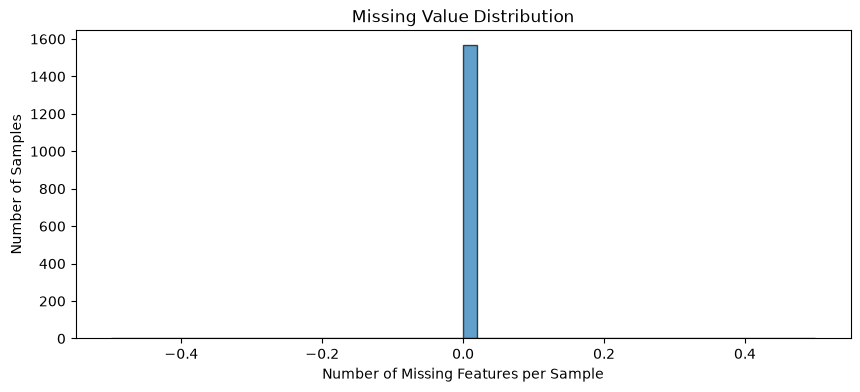

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(missing_per_sample, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Missing Features per Sample')
ax.set_ylabel('Number of Samples')
ax.set_title('Missing Value Distribution')
plt.show()


In [19]:
from sklearn.feature_selection import VarianceThreshold

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
X = data.drop('label', axis=1)
y = data['label']


In [22]:
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)
print(f"方差过滤后特征数: {X_selected.shape[1]}")

方差过滤后特征数: 314


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

RandomForestClassifier(random_state=42)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf.fit(X_scaled, y);

In [29]:
importances = rf.feature_importances_

In [30]:
top30_idx = np.argsort(importances)[-30:]

In [31]:
X_top30 = X_scaled[:, top30_idx]

In [32]:
print("变量已重新生成！importances 长度:", len(importances))

变量已重新生成！importances 长度: 314


In [34]:
selected_features = X.columns[selector.get_support()]

In [35]:
top30_feature_names = selected_features[top30_idx]

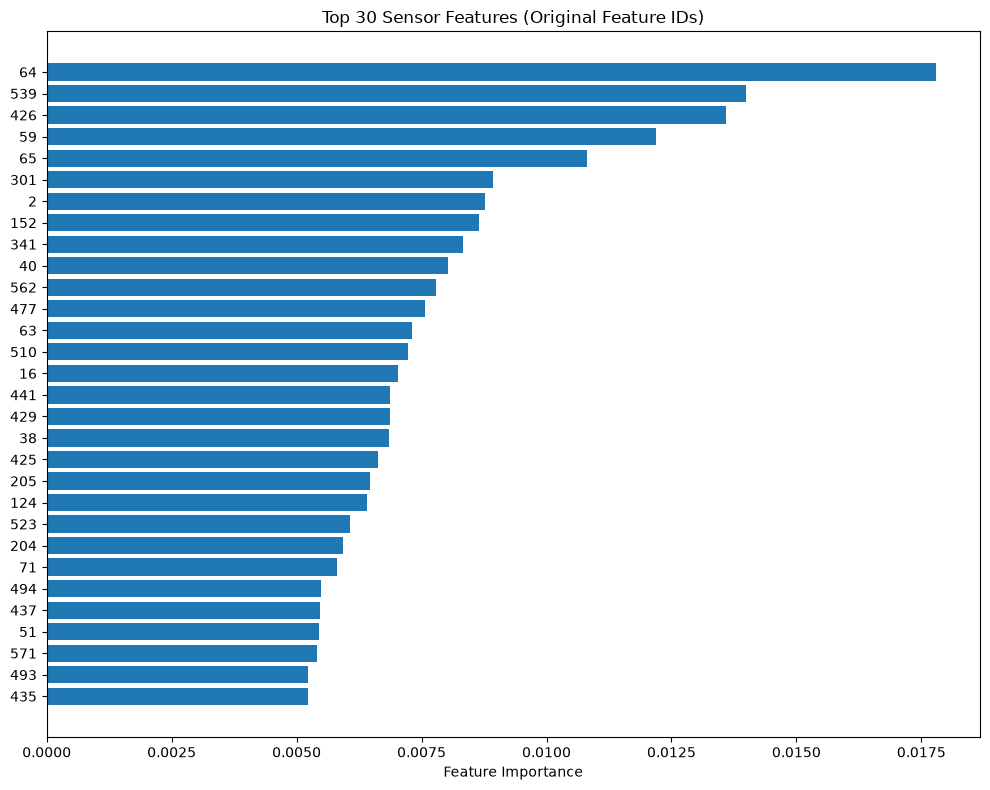

In [36]:
plt.figure(figsize=(10, 8))
plt.barh(range(30), importances[top30_idx], tick_label=top30_feature_names)
plt.xlabel('Feature Importance')
plt.title('Top 30 Sensor Features (Original Feature IDs)')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_top30, y, test_size=0.3, random_state=42, stratify=y
)

In [39]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.07,   # 估计异常比例，约7%
    random_state=42
)
iso.fit(X_train)

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

IsolationForest(contamination=0.07, n_estimators=200, random_state=42)

In [40]:
y_pred = iso.predict(X_test)

In [41]:
y_pred_secom = np.where(y_pred == -1, 1, -1)


In [42]:
print("预测完成")
print("预测为异常的样本数:", (y_pred_secom == 1).sum())

预测完成
预测为异常的样本数: 28


In [43]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_secom))
print(classification_report(y_test, y_pred_secom))

[[421  19]
 [ 22   9]]
              precision    recall  f1-score   support

          -1       0.95      0.96      0.95       440
           1       0.32      0.29      0.31        31

    accuracy                           0.91       471
   macro avg       0.64      0.62      0.63       471
weighted avg       0.91      0.91      0.91       471



In [44]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [45]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [46]:
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1] 

In [47]:
print("=== Gradient Boosting 结果 ===")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print("AUC:", roc_auc_score(y_test, y_prob_gb))

=== Gradient Boosting 结果 ===
[[432   8]
 [ 26   5]]
              precision    recall  f1-score   support

          -1       0.94      0.98      0.96       440
           1       0.38      0.16      0.23        31

    accuracy                           0.93       471
   macro avg       0.66      0.57      0.59       471
weighted avg       0.91      0.93      0.91       471

AUC: 0.7749266862170088


In [48]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score, classification_report

In [49]:
y_prob_gb = gb.predict_proba(X_test)[:, 1]

In [50]:
best_f1 = 0
best_threshold = 0.5
for threshold in np.arange(0.1, 0.9, 0.05):
    y_pred_tuned = np.where(y_prob_gb > threshold, 1, -1)
    f1 = f1_score(y_test, y_pred_tuned, pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"最佳阈值: {best_threshold:.2f}, 对应的F1: {best_f1:.2f}")


最佳阈值: 0.15, 对应的F1: 0.37


In [51]:
y_pred_best = np.where(y_prob_gb > best_threshold, 1, -1)
print("=== 调优阈值后的结果 ===")
print(classification_report(y_test, y_pred_best))

=== 调优阈值后的结果 ===
              precision    recall  f1-score   support

          -1       0.96      0.95      0.95       440
           1       0.35      0.39      0.37        31

    accuracy                           0.91       471
   macro avg       0.65      0.67      0.66       471
weighted avg       0.92      0.91      0.91       471



In [52]:
import matplotlib.pyplot as plt

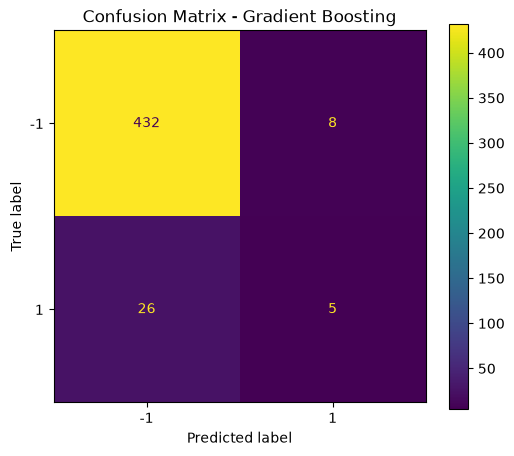

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, ax=ax)
ax.set_title('Confusion Matrix - Gradient Boosting')
plt.show()

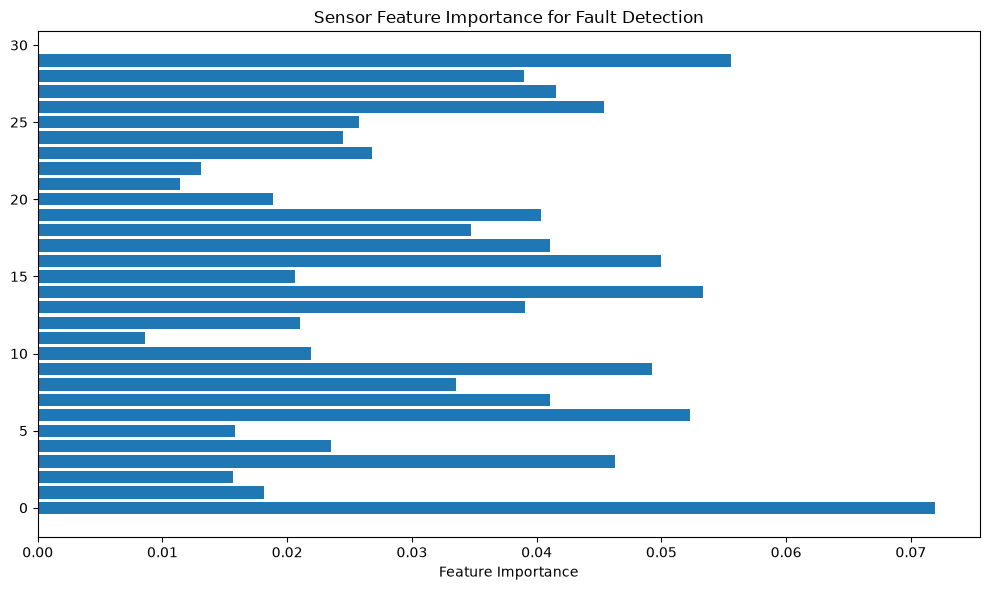

In [54]:
importances_gb = gb.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances_gb)), importances_gb)
plt.xlabel('Feature Importance')
plt.title('Sensor Feature Importance for Fault Detection')
plt.tight_layout()
plt.show()

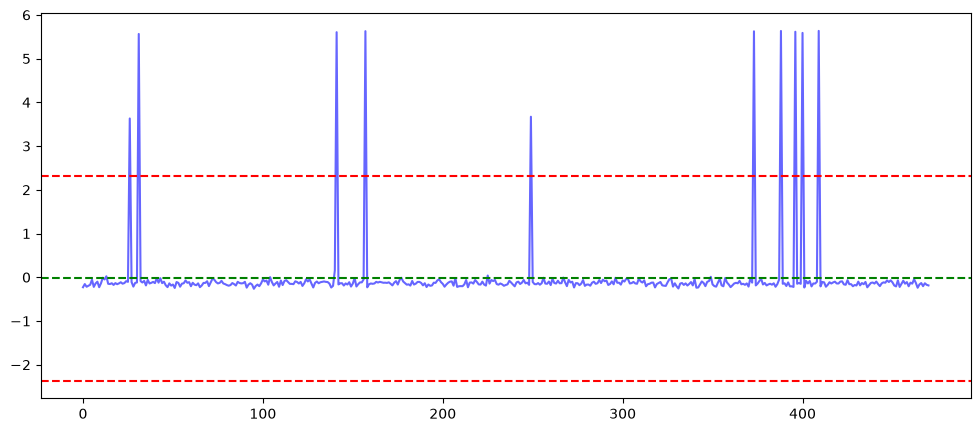

In [55]:
top_feature_idx = np.argmax(importances_gb)
top_feature_values = X_test[:, top_feature_idx]

mean_val = top_feature_values.mean()
std_val = top_feature_values.std()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(top_feature_values, 'b-', alpha=0.6, label='Sensor Value')
ax.axhline(mean_val, color='green', linestyle='--', label='Mean')
ax.axhline(mean_val + 3*std_val, color='red', linestyle='--', label='UCL (+3σ)')
ax.axhline(mean_val - 3*std_val, color='red', linestyle='--', label='LCL (-3σ)')


In [56]:
anomaly_idx = np.where(y_pred_gb == 1)[0]
ax.scatter(anomaly_idx, top_feature_values[anomaly_idx], 
           color='red', s=50, zorder=5, label='Detected Anomaly')

ax.set_xlabel('Sample Index')
ax.set_ylabel('Sensor Reading')
ax.set_title('SPC Control Chart - Key Sensor Feature')
ax.legend()
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [57]:
import matplotlib.pyplot as plt
import numpy as np

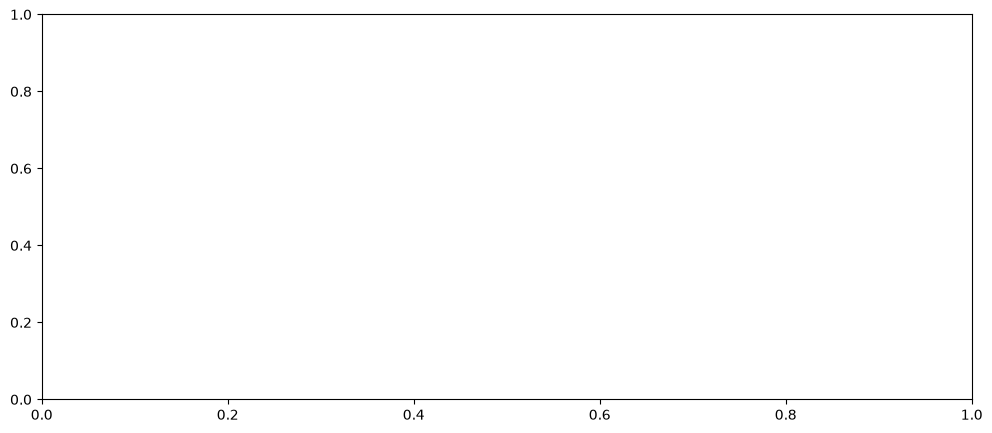

In [58]:
fig, ax = plt.subplots(figsize=(12, 5))

In [59]:
ax.plot(top_feature_values, 'b-', alpha=0.6, label='Sensor Value')

In [60]:
mean_val = top_feature_values.mean()
std_val = top_feature_values.std()

In [61]:
ax.axhline(mean_val, color='green', linestyle='--', label='Mean')
ax.axhline(mean_val + 3*std_val, color='red', linestyle='--', label='UCL (+3σ)')
ax.axhline(mean_val - 3*std_val, color='red', linestyle='--', label='LCL (-3σ)')

In [62]:
anomaly_idx = np.where(y_pred_gb == 1)[0]
ax.scatter(anomaly_idx, top_feature_values[anomaly_idx],
           color='red', s=50, zorder=5, label='Detected Anomaly')

In [63]:
ax.set_xlabel('Sample Index')
ax.set_ylabel('Sensor Reading')
ax.set_title('SPC Control Chart - Key Sensor Feature')
ax.legend()

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

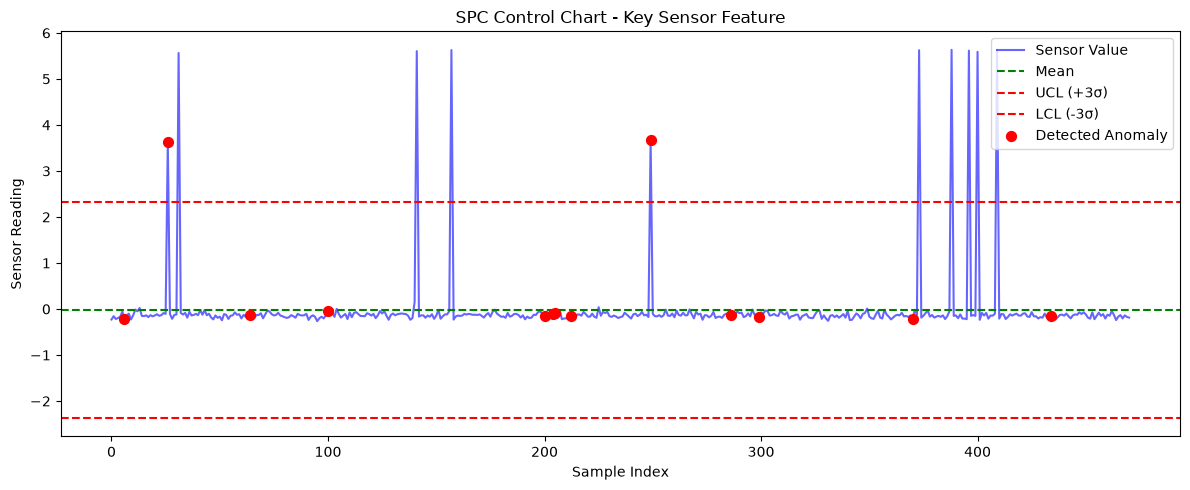

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 重新创建画布和坐标轴对象（最关键的一步！）
fig, ax = plt.subplots(figsize=(12, 5))

# 2. 画传感器折线
ax.plot(top_feature_values, 'b-', alpha=0.6, label='Sensor Value')

# 3. 计算均值和上下限
mean_val = top_feature_values.mean()
std_val = top_feature_values.std()

# 4. 画控制线
ax.axhline(mean_val, color='green', linestyle='--', label='Mean')
ax.axhline(mean_val + 3*std_val, color='red', linestyle='--', label='UCL (+3σ)')
ax.axhline(mean_val - 3*std_val, color='red', linestyle='--', label='LCL (-3σ)')

# 5. 标出异常点
anomaly_idx = np.where(y_pred_gb == 1)[0]
ax.scatter(anomaly_idx, top_feature_values[anomaly_idx],
           color='red', s=50, zorder=5, label='Detected Anomaly')

# 6. 加标签和图例
ax.set_xlabel('Sample Index')
ax.set_ylabel('Sensor Reading')
ax.set_title('SPC Control Chart - Key Sensor Feature')
ax.legend()

# 7. 显示图表
plt.tight_layout()
plt.show()

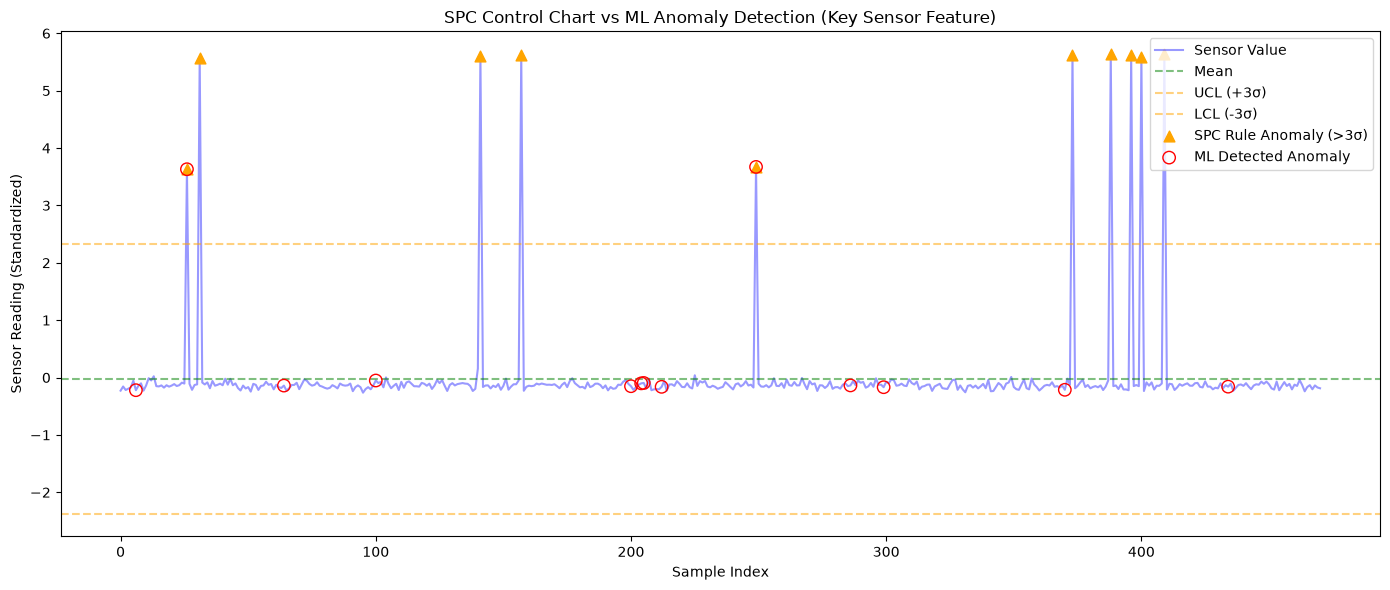

In [65]:
fig, ax = plt.subplots(figsize=(14, 6))

# 画主线
ax.plot(top_feature_values, 'b-', alpha=0.4, label='Sensor Value')

# 画控制线
mean_val = top_feature_values.mean()
std_val = top_feature_values.std()
ax.axhline(mean_val, color='green', linestyle='--', alpha=0.5, label='Mean')
ax.axhline(mean_val + 3*std_val, color='orange', linestyle='--', alpha=0.5, label='UCL (+3σ)')
ax.axhline(mean_val - 3*std_val, color='orange', linestyle='--', alpha=0.5, label='LCL (-3σ)')

# 1. 标出 SPC 规则的异常点（超过 3σ 的点）—— 用橙色三角形
spc_anomaly_idx = np.where((top_feature_values > mean_val + 3*std_val) | (top_feature_values < mean_val - 3*std_val))[0]
ax.scatter(spc_anomaly_idx, top_feature_values[spc_anomaly_idx], 
           color='orange', marker='^', s=60, zorder=4, label='SPC Rule Anomaly (>3σ)')

# 2. 标出机器学习模型预测的异常点 —— 用红色圆圈
ml_anomaly_idx = np.where(y_pred_gb == 1)[0]
ax.scatter(ml_anomaly_idx, top_feature_values[ml_anomaly_idx], 
           facecolors='none', edgecolors='red', s=80, zorder=5, label='ML Detected Anomaly')

ax.set_xlabel('Sample Index')
ax.set_ylabel('Sensor Reading (Standardized)')
ax.set_title('SPC Control Chart vs ML Anomaly Detection (Key Sensor Feature)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [66]:
!pip install shap -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
     ------------------ --------------------- 1.3/2.8 MB 6.7 MB/s eta 0:00:01
     ------------------------------------- -- 2.6/2.8 MB 7.9 MB/s eta 0:00:01
     ---------------------------------------- 2.8/2.8 MB 5.2 MB/s  0:00:00
     ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
     - -------------------------------------- 1.6/43.0 MB 34.6 MB/s eta 0:00:02
     -- ------------------------------------- 2.9/43.0 MB 11.4 MB/s eta 0:00:04
     ---- ----------------------------------- 5.0/43.0 MB 10.4 MB/s eta 0:00:04
     ------ --------------------------------- 7.1/43.0 MB 10.3 MB/s eta 0:00:04
     -------- ------------------------------- 8.7/43.0 MB 10.0 MB/s eta 0:00:04
     ---------- ----------------------------- 10.7/43.0 MB 9.8 MB/s eta 0:00:04
     ----------- ---------------------------- 12.6/43.0 MB 9.8 MB/s eta 0:00:04
     

In [71]:
import pandas as pd
import numpy as np

In [72]:
filtered_features = X.columns[selector.get_support()]

In [73]:
top30_feature_names = filtered_features[top30_idx]

In [74]:
X_test_df = pd.DataFrame(X_test, columns=top30_feature_names)

In [75]:
print("搞定！X_test_df 的形状是:", X_test_df.shape)
print("前5个特征名:", top30_feature_names[:5])

搞定！X_test_df 的形状是: (471, 30)
前5个特征名: Index([435, 493, 571, 51, 437], dtype='object')


In [76]:
import shap
import matplotlib.pyplot as plt

In [77]:
explainer = shap.TreeExplainer(gb)


In [78]:
ml_anomaly_idx = np.where(y_pred_gb == 1)[0]
if len(ml_anomaly_idx) > 0:
    sample_idx = ml_anomaly_idx[0]  # 选第一个异常样本
    print(f"正在解释测试集里的第 {sample_idx} 号样本...")

正在解释测试集里的第 6 号样本...


In [79]:
shap_values = explainer(X_test_df)

In [81]:
import matplotlib.pyplot as plt

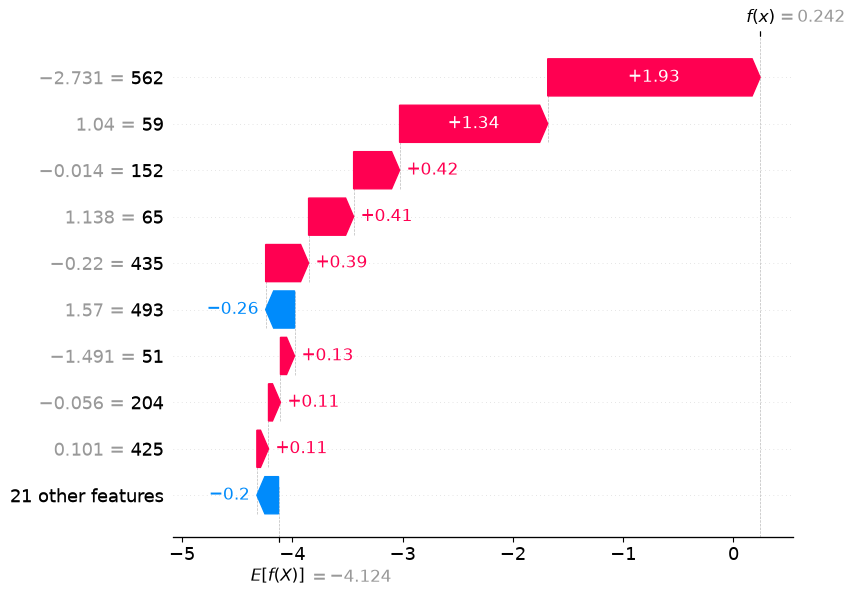

<Figure size 640x480 with 0 Axes>

In [82]:
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[sample_idx], max_display=10)
plt.tight_layout()
plt.show()